# CCGT+CCS NPV simulation

Run the CCGT+CCS electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import simulate_ccgt_ccs_npv


In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_ccgt_ccs_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2100.451278,43.520655,7.473855,1.939081,...,94070000.0,9.359281e+06,7.473855e+06,7.028959e+07,1.142018e+06,5.805256e+06,-3.897401e+08,25000000.0,-15.589606,-0.000016
1,1,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2129.655082,44.038330,6.160449,1.928964,...,94070000.0,9.470609e+06,6.160449e+06,8.622835e+07,2.144103e+06,-9.933505e+06,-5.640283e+08,25000000.0,-22.561132,-0.000023
2,2,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,1799.103583,43.404647,7.018329,1.927998,...,94070000.0,9.334333e+06,7.018329e+06,4.728494e+07,1.335917e+06,2.909648e+07,-7.630555e+07,25000000.0,-3.052222,-0.000003
3,3,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,1637.730026,41.380839,6.693105,1.922060,...,94070000.0,8.899105e+06,6.693105e+06,3.722307e+07,2.886581e+06,3.836814e+07,5.737133e+07,25000000.0,2.294853,0.000002
4,4,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2217.064977,46.204718,7.233210,1.916046,...,94070000.0,9.936499e+06,7.233210e+06,5.673476e+07,1.563411e+06,1.860212e+07,-2.782147e+08,25000000.0,-11.128587,-0.000011


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1.000000e+06
mean,-425.187752,-17.007510,-1.700751e-05
std,298.194562,11.927782,1.192778e-05
min,-1538.203886,-61.528155,-6.152816e-05
5%,-959.888932,-38.395557,-3.839556e-05
50%,-396.651303,-15.866052,-1.586605e-05
95%,12.899091,0.515964,5.159636e-07
max,257.043651,10.281746,1.028175e-05


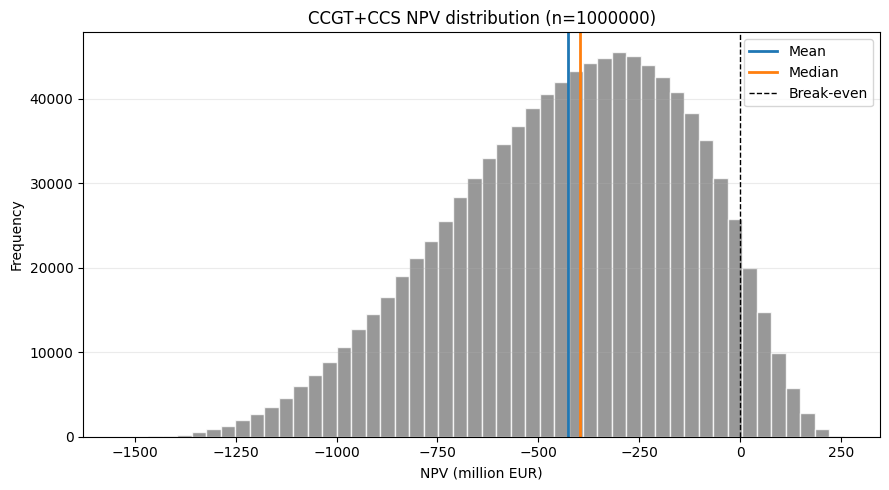

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


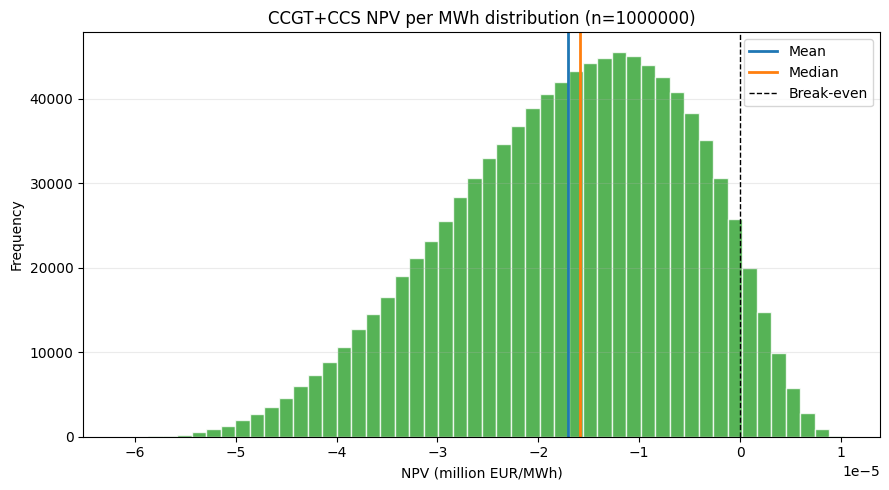

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.620260
annual_variable_opex_eur      6.277084
annual_fuel_cost_eur         75.462801
annual_emissions_cost_eur     1.792163
annual_net_cash_flow_eur      0.917693
Name: Mean annual value, million EUR, dtype: float64